In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Customer Churn.csv to Customer Churn.csv


In [ ]:
import os
print (os.listdir())

['.config', 'Customer Churn.csv', 'sample_data']


In [ ]:
import pandas as pd
df = pd.read_csv("Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df['customerID'].duplicated().sum()

np.int64(0)

In [ ]:
def conv(value):
  if value == 1:
     return "yes"
  else:
     return "no"
df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)



 #converted 0 and 1 values of senior ctizen to yes /no to ake it easier to understand

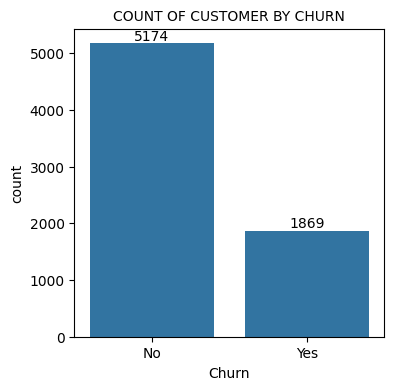

In [ ]:
plt.figure(figsize =(4,4))
ax = sns.countplot(x = 'Churn', data = df)


ax.bar_label(ax.containers[0])
plt.title("COUNT OF CUSTOMER BY CHURN",fontsize = 10)
plt.show()

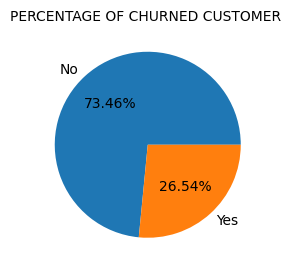

In [ ]:
plt.figure(figsize = (3,4))
gb = df.groupby('Churn').agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct= "%1.2f%%")
plt.title("PERCENTAGE OF CHURNED CUSTOMER ",fontsize = 10)
plt.show()

#from the given pie chart we can conclude that 26.54% of our customer have churned out .not let's explore the reason behind it

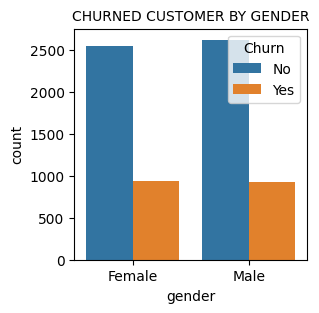

In [ ]:
plt.figure(figsize = (3,3))
sns.countplot(x = 'gender', data = df,hue = 'Churn')
plt.title("CHURNED CUSTOMER BY GENDER",fontsize = 10)
plt.show()

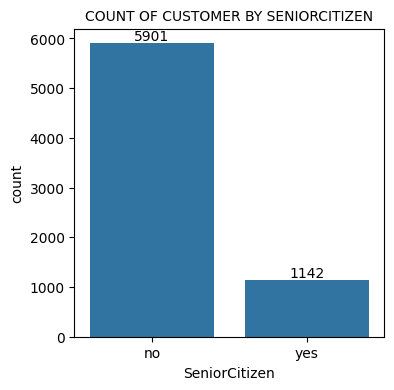

In [ ]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = 'SeniorCitizen', data=df)
ax.bar_label(ax.containers[0])
plt.title("COUNT OF CUSTOMER BY SENIORCITIZEN",fontsize = 10)
plt.show()

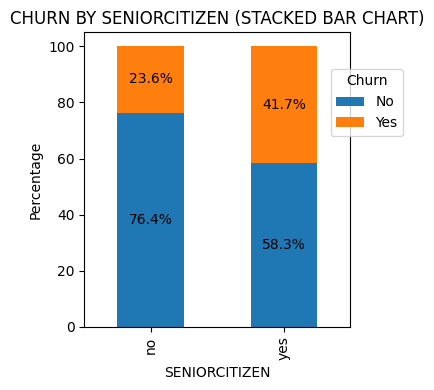

In [ ]:
# Create count table
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Convert counts to percentages within each SeniorCitizen group
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = ct_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(4, 4)
)

# Add percentage labels
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center')

plt.title('CHURN BY SENIORCITIZEN (STACKED BAR CHART)')
plt.xlabel('SENIORCITIZEN')
plt.ylabel('Percentage')
plt.legend(title='Churn',bbox_to_anchor = (0.9,0.9))
plt.tight_layout()
plt.show()

#comparative a greated pecentage of people in senior citizen category have churned

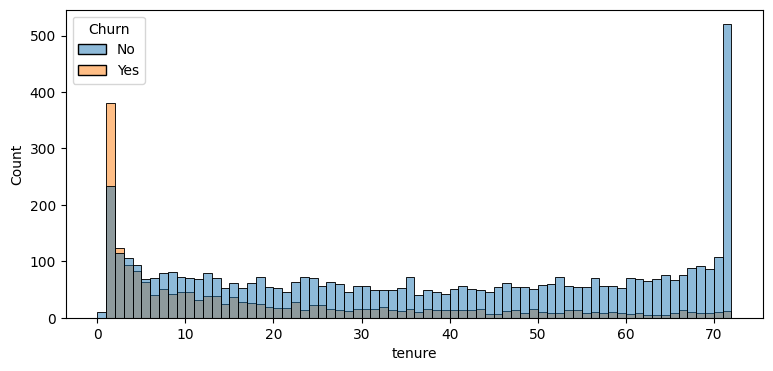

In [ ]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue = 'Churn')
plt.show()

In [ ]:
# people who have used our services for a long time have stayed and people who have used our sevices #1 or 2 months have churned

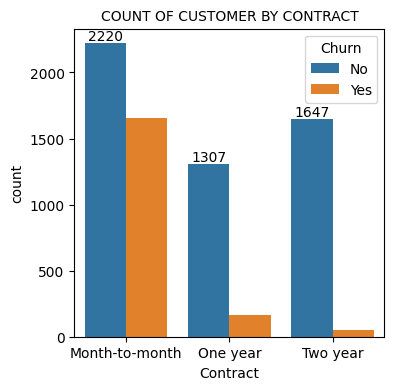

In [ ]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = 'Contract', data=df,hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title("COUNT OF CUSTOMER BY CONTRACT",fontsize = 10)
plt.show()

#people who have month to month contract are likely to churn then from those who have 1 or 2 years of contract

In [ ]:
print (df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


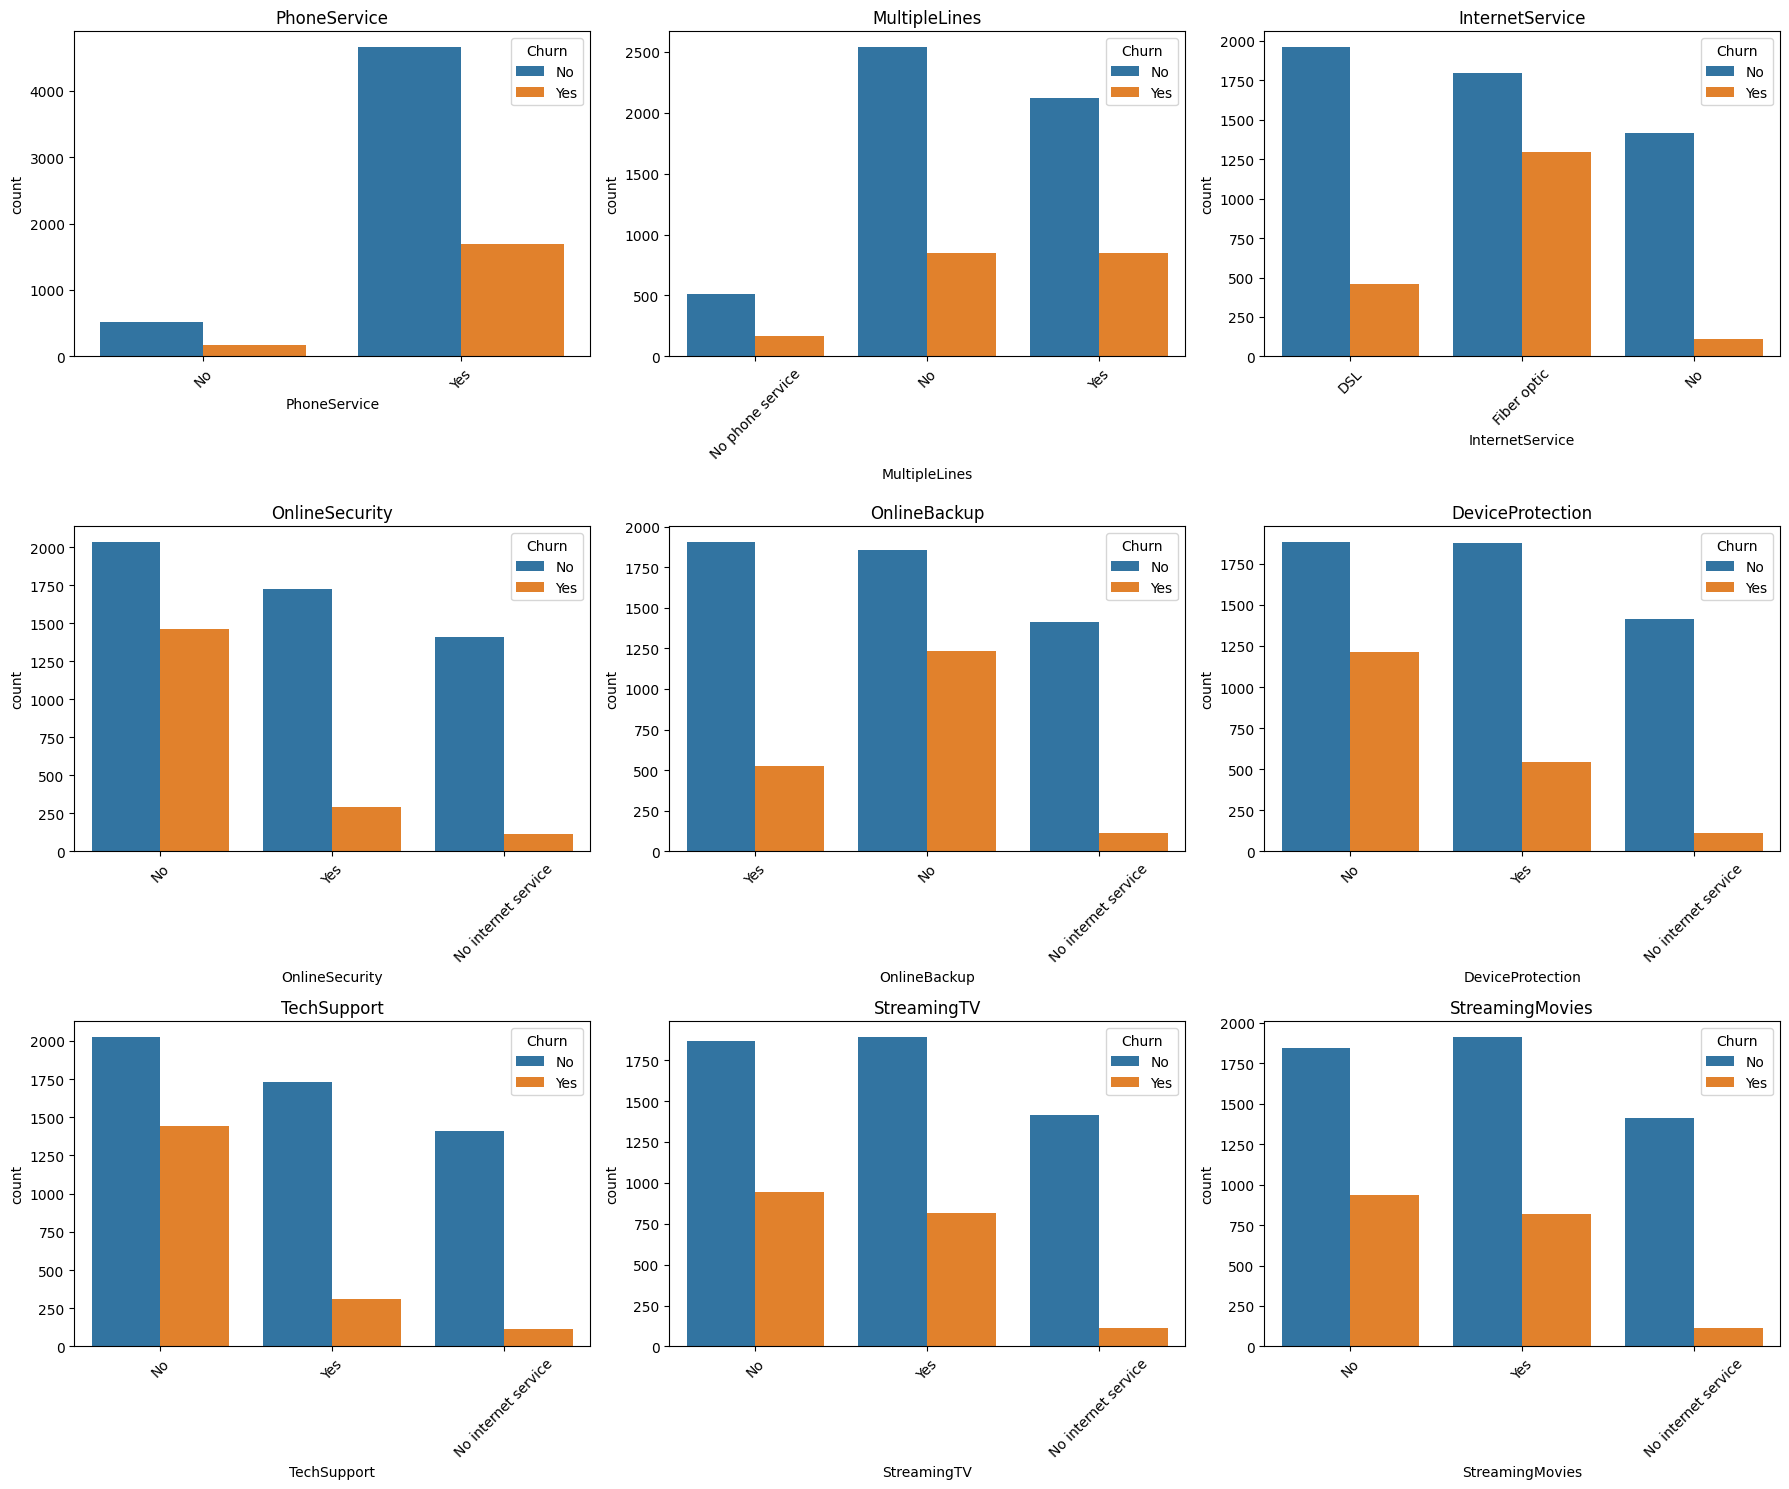

In [ ]:

cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplot grid (3 rows × 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i],hue = df['Churn'])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# The majority of custoers who do not chur tend to have services like PhoneServices , InternetServices (particularly DSL),and OnlineSecurity enabled . For sevices like OnlineBackup,TechSupport, and StreamingTV,churn rates noticeably higher when these services are not used or are unavaible.

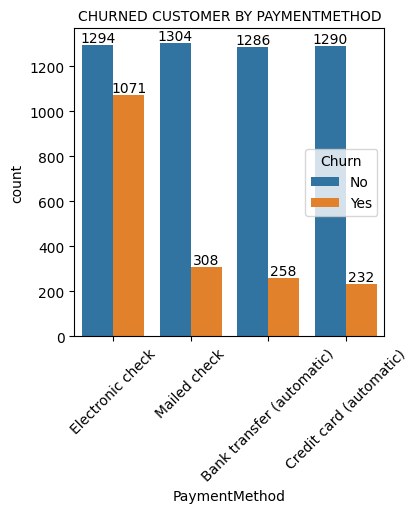

In [ ]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = 'PaymentMethod', data=df,hue = 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("CHURNED CUSTOMER BY PAYMENTMETHOD",fontsize = 10)
plt.xticks(rotation = 45)
plt.show()

#cuastomer is likely to churn when he is using electronic check as a payment method .

# • **Conclusion**



Overall Churn: Around 26.5% of customers have churned, while 73.5% remained with the company.

Gender: Customer churn is almost the same for both males and females; gender has little impact on churn.

Senior Citizen: Senior citizens have a higher churn rate than non-senior customers.

Tenure: Customers with shorter tenure are more likely to churn, while long-term customers tend to stay.

Contract Type: Month-to-month contracts have the highest churn, whereas one-year and two-year contracts show much lower churn.

Internet Service: Customers using Fiber Optic internet have the highest churn rate.

Payment Method: Customers paying through Electronic Check churn more frequently than those using other payment methods.

Paperless Billing: Customers with Paperless Billing are more likely to churn.

Online Security & Tech Support: Customers without Online Security or Tech Support have significantly higher churn.

Monthly Charges: Higher monthly charges are associated with higher churn.

Total Charges: Customers with higher total charges generally have lower churn, as they tend to be long-term customers.


#  **•Final** **Conclusion**

Customer churn is mainly influenced by contract type, tenure, monthly charges, internet service, and value-added services (Online Security and Tech Support). Customers with month-to-month contracts, high monthly bills, fiber optic service, and short tenure are the most likely to chur